**Fake Job Posting Detection using Machine Learning**

**OBJECTIVE:**


---
The objective of this project is to develop a machine learning model that can automatically classify job postings as fraudulent or legitimate using textual and structured information from job advertisements. The project involves data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and finally building a prediction system for unseen job postings.


Step 1 : Import Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
# Model Building
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

Step 2: Load Dataset

In [72]:
from google.colab import files
uploaded=files.upload()

Saving fake_job_postings.csv to fake_job_postings (1).csv


In [73]:
df=pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Step 3: Dataset Overview


In [74]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 17880
Columns : 18


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [76]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


Step 4: Check Missing Values

In [77]:
missing = df.isnull().sum()
missing = missing.sort_values(ascending=False)
missing


,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


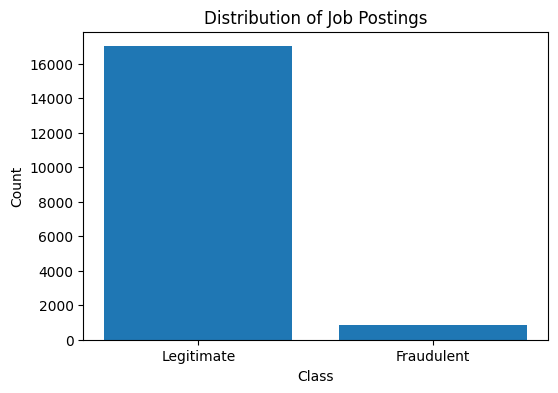

In [78]:
counts = df['fraudulent'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(['Legitimate', 'Fraudulent'], counts.values)
plt.title("Distribution of Job Postings")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Step 5: Check Duplicate Records

In [79]:
print("Duplicate Rows :", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows : 0


In [80]:
print("Column Names of the dataset:")
print(df.columns)

Column Names of the dataset:
Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')


In [81]:
df['employment_type'].value_counts()

,count
employment_type,
Full-time,11620
Contract,1524
Part-time,797
Temporary,241
Other,227


In [82]:
df['required_experience'].value_counts()

,count
required_experience,
Mid-Senior level,3809
Entry level,2697
Associate,2297
Not Applicable,1116
Director,389
Internship,381
Executive,141


In [83]:
df['required_education'].value_counts()

,count
required_education,
Bachelor's Degree,5145
High School or equivalent,2080
Unspecified,1397
Master's Degree,416
Associate Degree,274
Certification,170
Some College Coursework Completed,102
Professional,74
Vocational,49


Step 6 : Visualization

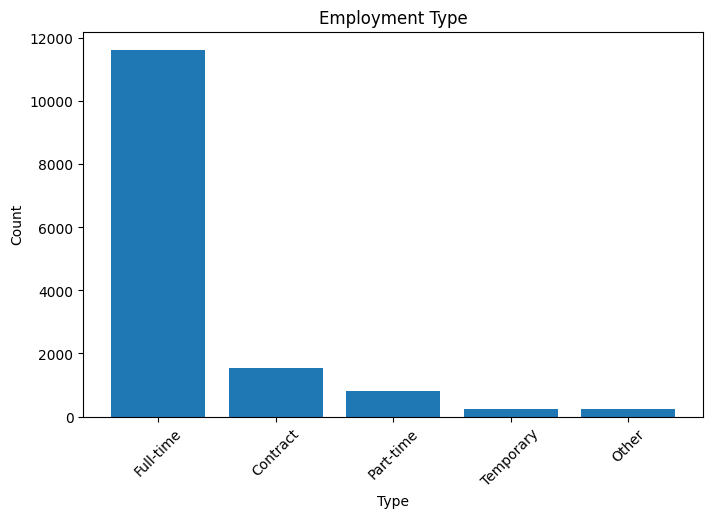

In [84]:
employment = df['employment_type'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(employment.index, employment.values)
plt.title("Employment Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

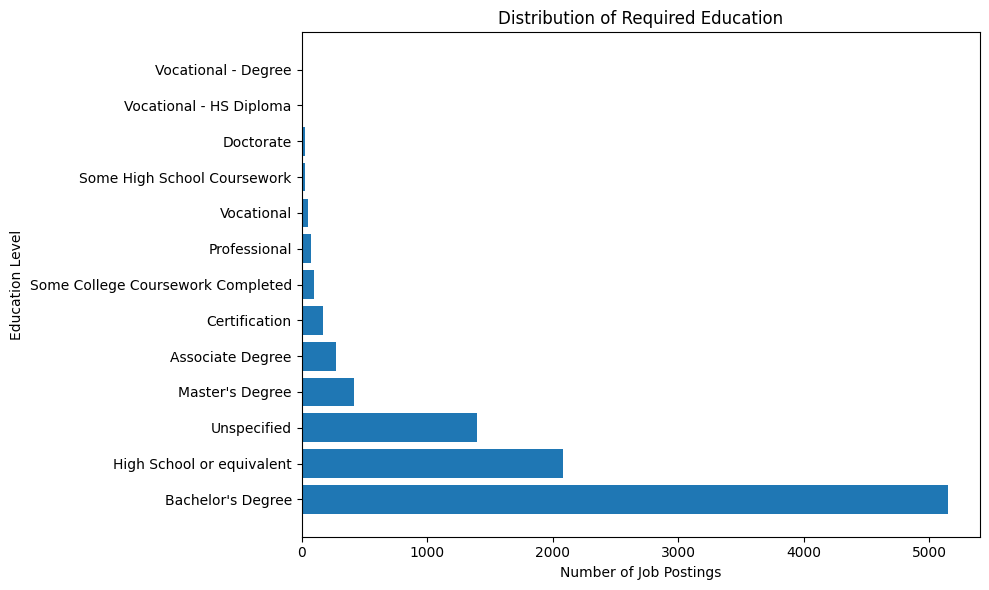

In [85]:
education = df['required_education'].value_counts()
plt.figure(figsize=(10,6))
plt.barh(education.index, education.values)
plt.title("Distribution of Required Education")
plt.xlabel("Number of Job Postings")
plt.ylabel("Education Level")
plt.tight_layout()
plt.show()

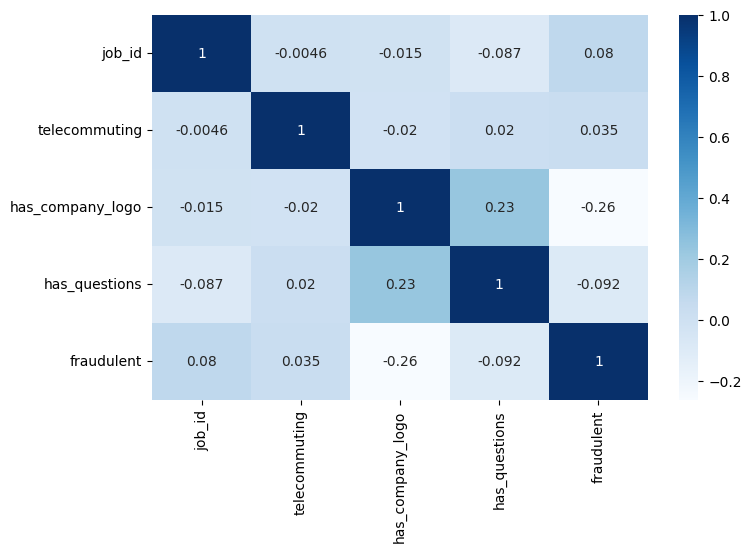

In [86]:
numerical = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(8,5))
sns.heatmap(numerical.corr(),annot=True,cmap='Blues')
plt.show()

Data Preprocessing & Text Cleaning

In [87]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


Fill Missing Values

In [88]:
text_columns = ['title','company_profile','description','requirements','benefits']
for column in text_columns:
    df[column] = df[column].fillna('')

Combine Text Columns

In [89]:
df['text'] = (
    df['title'] + " " +
    df['company_profile'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits']
)

In [90]:
df[['text']].head()

,text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


Create a Text Cleaning Function

In [91]:
import re
import string
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = " ".join(text.split())
    return text
df['text'] = df['text'].apply(clean_text)

In [92]:
print(df['text'].iloc[0])

marketing intern were food and weve created a groundbreaking and awardwinning cooking site we support connect and celebrate home cooks and give them everything they need in one placewe have a top editorial business and engineering team were focused on using technology to find new and better ways to connect people around their specific food interests and to offer them superb highly curated information about food and cooking we attract the most talented home cooks and contributors in the country we also publish wellknown professionals like mario batali gwyneth paltrow and danny meyer and we have partnerships with whole foods market and random housefood has been named the best food website by the james beard foundation and iacp and has been featured in the new york times npr pando daily techcrunch and on the today showwere located in chelsea in new york city food a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing 

Check for Empty Rows

In [93]:
df[df['text'].str.len() == 0]
df = df[df['text'].str.len() > 0]

In [94]:
df[['text', 'fraudulent']].head()

,text,fraudulent
0,marketing intern were food and weve created a ...,0
1,customer service cloud video production second...,0
2,commissioning machinery assistant cma valor se...,0
3,account executive washington dc our passion fo...,0
4,bill review manager spotsource solutions llc i...,0


Feature Engineering & Text Vectorization

In [95]:
X = df['text']
y = df['fraudulent']

In [96]:
X

,text
0,marketing intern were food and weve created a ...
1,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...
3,account executive washington dc our passion fo...
4,bill review manager spotsource solutions llc i...
...,...
17875,account director distribution vend is looking ...
17876,payroll accountant weblinc is the ecommerce pl...
17877,project cost control staff engineer cost contr...
17878,graphic designer nemsia studios is looking for...


In [97]:
y

,fraudulent
0,0
1,0
2,0
3,0
4,0
...,...
17875,0
17876,0
17877,0
17878,0


In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [99]:
X = tfidf.fit_transform(X)

In [100]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:50])

['aan' 'ab' 'abc' 'abilities' 'ability' 'able' 'abreast' 'abroad'
 'absolute' 'absolutely' 'academic' 'academy' 'accelerate' 'accelerator'
 'accept' 'acceptable' 'acceptance' 'accepted' 'accepting' 'access'
 'accessibility' 'accessible' 'accessories' 'accident' 'accommodate'
 'accommodation' 'accommodations' 'accommodationswillingness' 'accomplish'
 'accomplished' 'accordance' 'according' 'accordingly' 'account'
 'accountabilities' 'accountability' 'accountable' 'accountant'
 'accountants' 'accounting' 'accounts' 'accountslife' 'accredited'
 'accuracy' 'accurate' 'accurately' 'achieve' 'achieved' 'achievement'
 'achievements']


In [101]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

Model Building & Evaluation

In [102]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)

In [103]:
#Train the model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [104]:
lr_predictions = lr_model.predict(X_test)

In [105]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Accuracy:{lr_accuracy*100} %")

Accuracy:97.25950782997764 %


In [106]:
#Classification Report
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3395
           1       1.00      0.46      0.63       181

    accuracy                           0.97      3576
   macro avg       0.99      0.73      0.81      3576
weighted avg       0.97      0.97      0.97      3576



In [107]:
#Confusion Matrix
cm = confusion_matrix(y_test, lr_predictions)
print(cm)

[[3395    0]
 [  98   83]]


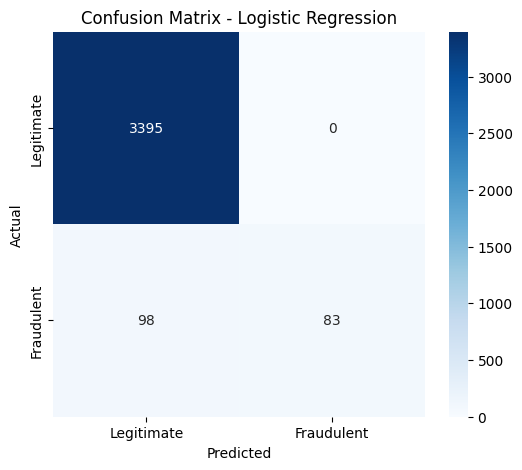

In [108]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legitimate', 'Fraudulent'],yticklabels=['Legitimate', 'Fraudulent'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model 2: Naive Bayes

In [117]:
nb_model = MultinomialNB()

In [118]:
#Train the model
nb_model.fit(X_train, y_train)

MultinomialNB()

In [119]:
nb_predictions = nb_model.predict(X_test)

In [120]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
print("Accuracy:", nb_accuracy)

Accuracy: 0.9664429530201343


In [121]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3395
           1       1.00      0.34      0.50       181

    accuracy                           0.97      3576
   macro avg       0.98      0.67      0.74      3576
weighted avg       0.97      0.97      0.96      3576



In [122]:
nb_cm = confusion_matrix(y_test, nb_predictions)
print(nb_cm)

[[3395    0]
 [ 120   61]]


Model 3: Random Forest

In [114]:
#Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [115]:
#Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [123]:
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Accuracy:", rf_accuracy)

Accuracy: 0.9801454138702461


In [124]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.99      0.61      0.76       181

    accuracy                           0.98      3576
   macro avg       0.99      0.81      0.87      3576
weighted avg       0.98      0.98      0.98      3576



In [125]:
rf_cm = confusion_matrix(y_test, rf_predictions)
print(rf_cm)

[[3394    1]
 [  70  111]]


Model Improvement & Experimentation

In [135]:
# Convert text using CountVectorizer
count_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=5000
)
X_count = count_vectorizer.fit_transform(df['text'])

In [136]:
# Train-Test Split
X_train_count, X_test_count, y_train_count, y_test_count = train_test_split(X_count,y,test_size=0.2,random_state=42)

In [140]:
# Logistic Regression using CountVectorizer
lr_count = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_count.fit(X_train_count, y_train_count)
count_predictions = lr_count.predict(X_test_count)
count_accuracy = accuracy_score( y_test_count,count_predictions)
print(f"CountVectorizer Accuracy :{count_accuracy*100} %")

CountVectorizer Accuracy :98.37807606263982 %


In [141]:
comparing_vectorizer = pd.DataFrame({
    "Vectorizer": ["CountVectorizer", "TF-IDF"],
    "Accuracy": [count_accuracy, lr_accuracy]
})

comparing_vectorizer

,Vectorizer,Accuracy
0,CountVectorizer,0.983781
1,TF-IDF,0.972595


Hyperparameter Tuning

In [142]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_tuned_predictions = rf_tuned.predict(X_test)
rf_tuned_accuracy = accuracy_score(
    y_test,
    rf_tuned_predictions
)
print("Tuned Random Forest Accuracy :", rf_tuned_accuracy)

Tuned Random Forest Accuracy : 0.9703579418344519


In [143]:
rf_compare = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        rf_accuracy,
        rf_tuned_accuracy
    ]
})
rf_compare

,Model,Accuracy
0,Random Forest,0.980145
1,Tuned Random Forest,0.970358


Comparing all the 3 Models

In [144]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        rf_tuned_accuracy
    ]
})
results = results.sort_values(
    by="Accuracy",
    ascending=False
)
results

,Model,Accuracy
2,Random Forest,0.980145
0,Logistic Regression,0.972595
3,Tuned Random Forest,0.970358
1,Naive Bayes,0.966443


In [146]:
comparison_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, rf_tuned_predictions)
    ],

    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, nb_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, rf_tuned_predictions)
    ],

    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, nb_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, rf_tuned_predictions)
    ],

    "F1-Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, nb_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, rf_tuned_predictions)
    ]
})

comparison_metrics = comparison_metrics.round(4)

comparison_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9726,1.0000,0.4586,0.6288
1,Naive Bayes,0.9664,1.0000,0.3370,0.5041
2,Random Forest,0.9801,0.9911,0.6133,0.7577
3,Tuned Random Forest,0.9704,1.0000,0.4144,0.5859


In [147]:
#Best Model
best_model = comparison_metrics.loc[
    comparison_metrics["Accuracy"].idxmax()
]

print(best_model)

Model        Random Forest
Accuracy            0.9801
Precision           0.9911
Recall              0.6133
F1-Score            0.7577
Name: 2, dtype: object


**Prediction system for unseen job postings**


---
How does the prediction system work?

New Job Posting

        ↓

Text Cleaning

        ↓

TF-IDF Transformation

        ↓

Trained Logistic Regression Model

        ↓

Prediction

        ↓

Legitimate or Fraudulent





In [131]:
def predict_job_posting(job_text):

    cleaned_text = clean_text(job_text)
    transformed_text = tfidf.transform([cleaned_text])
    prediction = rf_model.predict(transformed_text)
    probability = rf_model.predict_proba(transformed_text)
    confidence = probability.max() * 100
    if prediction[0] == 1:
        print("Prediction: Fraudulent Job Posting")
    else:
        print("Prediction: Legitimate Job Posting")

    print(f"Confidence: {confidence:.2f}%")

In [132]:
job1 = """
Software Engineer

ABC Technologies Pvt Ltd is hiring a Python Developer.

Requirements:
Bachelor's Degree
Python
Machine Learning
SQL

Benefits:
Health Insurance
Paid Leave
"""

predict_job_posting(job1)

Prediction: Legitimate Job Posting
Confidence: 84.00%


In [133]:
job2 = """
Earn ₹1,00,000 per week.
No experience needed.
Work from home.

Pay a registration fee.

Limited vacancies.
Apply immediately.
"""

predict_job_posting(job2)

Prediction: Fraudulent Job Posting
Confidence: 52.00%


In [145]:
user_job = input("Enter the job posting:\n")
predict_job_posting(user_job)

Enter the job posting:
URGENT HIRING!!!  Work from home and earn ₹1,00,000 per week.  No experience required. No interview. Limited vacancies.  Pay ₹500 registration fee immediately.  Apply now! Prediction: Fraudulent Job Posting
Prediction: Fraudulent Job Posting
Confidence: 58.00%


**Conclusion:**


---
This project developed a machine learning system to detect fraudulent job postings using NLP techniques. After preprocessing the data and converting text using TF-IDF, multiple classification models were trained and evaluated. Random Forest achieved the best overall performance and was selected as the final model. The developed prediction system can classify unseen job postings as legitimate or fraudulent, helping identify potential employment scams.